In [3]:
import sys

!{sys.executable} -m pip install -U pip
!{sys.executable} -m pip install -U torch --index-url https://download.pytorch.org/whl/cu128
!{sys.executable} -m pip install -U optuna

Looking in indexes: https://download.pytorch.org/whl/cu128


In [4]:
import os
import torch
import optuna
from torch.nn import Sigmoid
from dataclasses import dataclass
import matplotlib.pyplot as plt


C:\Users\Luco1421\Desktop\U\ia\TPs\TP3\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
os.environ['PYTORCH_CUDA_ALLOC_CONF'] = 'expandable_segments:True'

TYPE = torch.float32

In [6]:
class Visualization :
    """! Utility class for data visualization.

    Provides methods for converting tensors into NumPy arrays
    and generating different types of plots for analysis.
    """

    @staticmethod
    def change_tensor(t):
        """ ! Converts a PyTorch tensor into a NumPy array.

        @param t Input object that may be a tensor.
        @return NumPy array if t is a tensor, otherwise the original object.
        """

        # Check whether the input is a PyTorch tensor
        if isinstance(t,torch.Tensor):

            # Detach tensor from graph, move to CPU, and convert to NumPy
            return t.detach().cpu().numpy()

        # Return original object if it is not a tensor
        return t

    def make_scatter(self, x, y, c):
        """! Generates a scatter plot.

        @param x Values for the X-axis.
        @param y Values for the Y-axis.
        @param c Values used for point coloring.
        """
        # Create a new figure
        plt.figure()

        # Generate scatter plot
        plt.scatter(self.change_tensor(x), self.change_tensor(y), c=self.change_tensor(c))

        # Set plot title
        plt.title("Diagrama de Dipersión")

        # Label X-axis
        plt.xlabel("Eje X")

        # Label Y-axis
        plt.ylabel("Eje Y")

        # Adjust layout spacing
        plt.tight_layout()

        # Display plot
        plt.show()

    def make_error_plot(self, history_error, title : str):
        """! Plots the error history over iterations.

        @param history_error List or tensor containing error values.
        @param title Title prefix for the graph.
        """

        # Create a new figure
        plt.figure()

        # Plot error history
        plt.plot(self.change_tensor(history_error))

        # Set plot title
        plt.title(f"{title} - Gráfica de Error")

        # Label X-axis
        plt.xlabel("Iteración")

        # Label Y-axis
        plt.ylabel("Error")

        # Display plot
        plt.show()

    def make_scatter_with_line(self, x, y, c, y_line, title : str):
        """ ! Generates a scatter plot with a decision boundary line.

        @param x Values for the X-axis.
        @param y Values for the Y-axis.
        @param c Values used for point coloring.
        @param y_line Values representing the line to plot.
        @param title Plot title suffix.
        """

        # Create a new figure
        plt.figure()

        # Generate scatter plot
        plt.scatter(self.change_tensor(x), self.change_tensor(y), c=self.change_tensor(c))

        # Plot decision boundary line
        plt.plot(self.change_tensor(x), self.change_tensor(y_line))

        #:Set plot title
        plt.title(f"Diagrama de Disperción {title} con la superficie de decisión")

        # Label X-axis
        plt.xlabel("Eje X")

        # Label Y-axis
        plt.ylabel("Eje Y")

        # Display plot
        plt.show()

# Global visualization utility instance
visualization = Visualization()

In [7]:
class MultilayerPerceptron:
    def __init__(self, neurons_per_layer : list [int], alpha : float, gamma : float, max_weights : float):
        self.d, self.m, self.k = neurons_per_layer

        self.alpha = alpha
        self.gamma = gamma
        self.max_weights = max_weights

        self.W_o = torch.rand(self.d, self.m, dtype=TYPE).clamp(max=self.max_weights)
        self.W_s = torch.rand(self.m, self.k, dtype=TYPE).clamp(max=self.max_weights)

        self.delta_W_o = torch.zeros(self.d, self.m, dtype=TYPE)
        self.delta_W_s = torch.zeros(self.m, self.k, dtype=TYPE)

        self.P_o = torch.zeros(self.d, self.m, dtype=TYPE)
        self.Y_o = torch.zeros(self.d, self.m, dtype=TYPE)
        self.P_s = torch.zeros(self.m, self.k, dtype=TYPE)
        self.Y_s = torch.zeros(self.m, self.k, dtype=TYPE)

        self.activation = Sigmoid()

        self.V_o = torch.zeros(self.d, self.m, dtype=TYPE)
        self.V_s = torch.zeros(self.m, self.k, dtype=TYPE)

    def forward(self, X : torch.Tensor):
        self.P_o = X @ self.W_o
        self.Y_o = self.activation(self.P_o)
        self.P_s = self.Y_o @ self.W_s
        self.Y_s = self.activation(self.P_s)

    def backpropagate_deltas(self, T: torch.Tensor):
        # Output layer
        self.delta_W_s =  (self.Y_s - T) * (self.Y_s * (1 - self.Y_s))

        # Hidden layer
        self.delta_W_o = (self.delta_W_s  @ self.W_s.T) * self.Y_o * (1 - self.Y_o)

    def update_weights(self, X: torch.Tensor):
        # Hidden Layer
        self.V_o = self.V_o * self.gamma + self.alpha * (1 - self.gamma) * (X.T @ self.delta_W_o)
        self.W_o = (self.W_o - self.V_o).clamp(max=self.max_weights)

        # Output Layer
        self.V_s = self.V_s * self.gamma + self.alpha * (1 - self.gamma) * (self.Y_o.T @ self.delta_W_s)
        self.W_s = (self.W_s - self.V_s).clamp(max=self.max_weights)

    def get_error(self, T: torch.Tensor):
        return (((T - self.Y_s) ** 2).sum() / T.shape[0]).item()

    def train_mlp(self, nun_epochs: int, X : torch.Tensor, T : torch.Tensor, alpha : float | None = None, gamma : float | None = None):
        if alpha is not None:
            self.alpha = alpha
        if gamma is not None:
            self.gamma = gamma

        history_error = []

        for _ in range(nun_epochs):
            self.forward(X)
            self.backpropagate_deltas(T)
            self.update_weights(X)
            history_error.append(self.get_error(T))

        return history_error

## Test Forward

In [8]:
X = torch.tensor([[1, 0], [0, 1]], dtype=TYPE)

def test_forward(X):
    entry_layer_dim = 2
    hidden_layer_dim = 2
    output_layer_dim = 2
    alpha = 0.01
    gamma = 0.9
    max_weights = 1
    mp = MultilayerPerceptron([entry_layer_dim, hidden_layer_dim, output_layer_dim], alpha, gamma, max_weights)
    mp.forward(X)
    assert mp.Y_s.shape[0] == output_layer_dim

test_forward(X)

In [9]:

@dataclass
class DataXOR:
    X = torch.tensor([
        [1, 0, 0],
        [1, 0, 1],
        [1, 1, 0],
        [1, 1, 1]
    ], dtype=TYPE)
    T = torch.tensor([
        [1,0],
        [0,1],
        [0,1],
        [1,0]
    ], dtype=TYPE)
    M = 2


In [10]:
def study():
    def objetive(trial):
        alpha = trial.suggest_float("alpha", 5, 7, log=True)
        gamma = trial.suggest_float("gamma", 1e-20, 1e-5, log=True)
        mp = MultilayerPerceptron([3, DataXOR.M, 2], alpha, gamma, 1000)
        history_error = mp.train_mlp(5000, DataXOR.X, DataXOR.T)
        return history_error[-1]

    stud = optuna.create_study(direction="minimize")
    stud.optimize(objetive, n_trials=50)
    optuna.visualization.plot_optimization_history(stud).show()
    optuna.visualization.plot_rank(stud).show()
    optuna.visualization.plot_param_importances(stud).show()
    return stud.best_params

study()

[I 2026-05-28 17:47:57,634] A new study created in memory with name: no-name-1a9cd39a-e8cc-46c7-935a-321ab33059b5
[I 2026-05-28 17:47:58,306] Trial 0 finished with value: 0.25005513429641724 and parameters: {'alpha': 6.915801068566163, 'gamma': 8.369431982333768e-14}. Best is trial 0 with value: 0.25005513429641724.
[I 2026-05-28 17:47:58,978] Trial 1 finished with value: 0.0004938214551657438 and parameters: {'alpha': 5.180839898355731, 'gamma': 5.861341894677861e-14}. Best is trial 1 with value: 0.0004938214551657438.
[I 2026-05-28 17:47:59,958] Trial 2 finished with value: 0.00047092209570109844 and parameters: {'alpha': 5.46868273519191, 'gamma': 1.240314960259126e-15}. Best is trial 2 with value: 0.00047092209570109844.
[I 2026-05-28 17:48:00,685] Trial 3 finished with value: 0.25007137656211853 and parameters: {'alpha': 5.502307446142867, 'gamma': 4.346983552248234e-07}. Best is trial 2 with value: 0.00047092209570109844.
[I 2026-05-28 17:48:01,339] Trial 4 finished with value: 0

ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

0.00035211470094509423
tensor([[0.9849, 0.0151],
        [0.0111, 0.9889],
        [0.0111, 0.9889],
        [0.9849, 0.0151]])


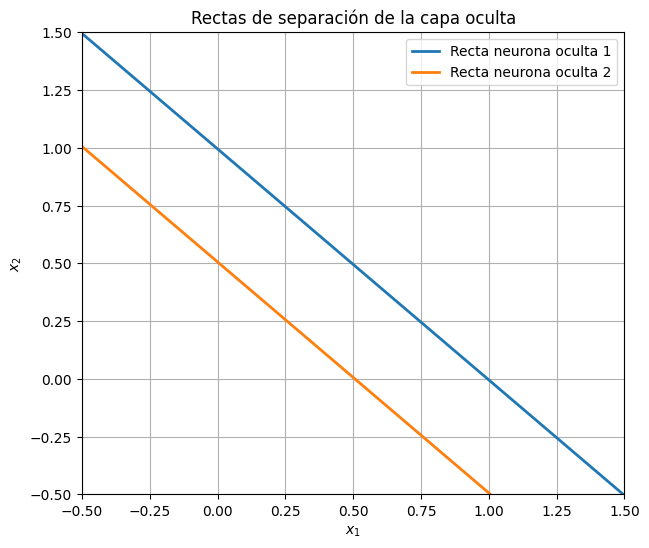

In [43]:
import numpy as np

def graficar_rectas_ocultas(W, xlim=(-0.5, 1.5), ylim=(-0.5, 1.5)):

    x1 = np.linspace(xlim[0], xlim[1], 300)

    plt.figure(figsize=(7, 6))

    # Rectas de las dos neuronas ocultas
    for j in range(2):
        w1 = W[1, j]
        w2 = W[2, j]
        bj = W[0, j]

        if abs(w2) > 1e-8:
            x2 = -(w1 * x1 + bj) / w2
            plt.plot(x1, x2, linewidth=2, label=f"Recta neurona oculta {j+1}")
        else:
            # Caso recta vertical: w1*x1 + b = 0
            x_vertical = -bj / w1
            plt.axvline(x_vertical, linewidth=2, label=f"Recta neurona oculta {j+1}")
    plt.xlim(xlim)
    plt.ylim(ylim)
    plt.xlabel("$x_1$")
    plt.ylabel("$x_2$")
    plt.title("Rectas de separación de la capa oculta")
    plt.grid(True)
    plt.legend()
    plt.show()

mp = MultilayerPerceptron([3, DataXOR.M, 2], 5.758356134379854, 1.1509357541768894e-11, 1000)
err = mp.train_mlp(5000, DataXOR.X, DataXOR.T)
print(err[-1])
print(mp.Y_s)
graficar_rectas_ocultas(mp.W_o.detach().cpu().numpy())